# Validate the Python minispect radiance-spectrum estimate

Load every example world-camera measurement, run both MATLAB `estimateRadianceSpectrumFromMinispect` and Python `estimate_radiance_spectrum_form_ms`, and quantify agreement for the reconstructed spectrum, wavelength sampling, residual norm (`fVal`), and per-channel fit errors. The notebook uses one MATLAB Engine session for the complete validation run.

> **Prerequisite.** `ms_util` reads `data/ASM7341_spectralSensitivity_numeric.mat`.
> The canonical `data/ASM7341_spectralSensitivity.mat` stores the sensitivity as a
> MATLAB `table` object, which `scipy.io.loadmat` cannot read, so a plain numeric
> companion file is used instead. That companion is a generated artifact and is
> listed in `.gitignore`. If importing `ms_util` fails with a missing-file error,
> regenerate it once from MATLAB:
>
> ```matlab
> exportASM7341NumericSensitivity
> ```
>
> The function lives in `code/defineWorldCameraCalibration/empiricalDataPrep/` and
> writes the same max-normalized `miniSpectT` and `miniSpectWls` variables that
> `estimateRadianceSpectrumFromMinispect.m` builds from the table.

In [1]:
# Import the Python libraries used for paths, numerical calculations, tables, plotting,
# MATLAB-file loading, and communication with MATLAB.
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import matlab.engine


# First, define some paths we are going to reuse.
PROJECT_ROOT: Path = Path("/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis")
CODE_ROOT: Path = PROJECT_ROOT / "code"
EXAMPLE_DATA_DIR: Path = PROJECT_ROOT / "data" / "exampleWorldCameraImages"
SENSOR_UTILITY_DIR: Path = CODE_ROOT / "library" / "sensor_utility"

# Add our sensor utility folder to Python's module search path so ms_util can be imported.
sys.path.append(str(SENSOR_UTILITY_DIR))
import ms_util

print(f"Project root: {PROJECT_ROOT}")

/opt/anaconda3/lib/python3.13/site-packages/matlabengine-25.2-py3.13.egg/matlab/__init__.py:158: UserWarning: Python versions 3.9, 3.10, 3.11, and 3.12 are supported, but your version of Python is 3_13
  warnings.warn('Python versions 3.9, 3.10, 3.11, and 3.12 are supported, but your version of Python is %s' % _version)
/opt/anaconda3/lib/python3.13/site-packages/matlabengine-25.2-py3.13.egg/matlab/engine/__init__.py:43: UserWarning: MATLAB Engine for Python supports Python version 3.9, 3.10, 3.11, and 3.12, but your version of Python is 3_13
  warnings.warn('MATLAB Engine for Python supports Python version'


Project root: /Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis


In [2]:
# Next, let's load in the measurement paths.
# glob finds every example MAT file whose name contains _AGCandMS_. Sorting the
# paths makes the processing and output order reproducible.
measurement_paths: list[Path] = sorted(EXAMPLE_DATA_DIR.glob("*_AGCandMS_*.mat"))
if not measurement_paths:
    raise FileNotFoundError(f"No example measurements found in {EXAMPLE_DATA_DIR}")

print(f"Found {len(measurement_paths)} measurements:")
for measurement_path in measurement_paths:
    print(f"  {measurement_path.name}")

Found 7 measurements:
  indoor_AGCandMS_01.mat
  indoor_AGCandMS_02.mat
  indoor_AGCandMS_03.mat
  outdoor_AGCandMS_01.mat
  outdoor_AGCandMS_02.mat
  outdoor_AGCandMS_03.mat
  planetarium_AGCandMS_01.mat


In [3]:
def compare_spectrum_results(
    measurement_name: str,
    matlab_spectrum: np.ndarray,
    python_spectrum: np.ndarray,
    matlab_sampling: np.ndarray,
    python_sampling: np.ndarray,
    matlab_f_val: float,
    python_f_val: float,
    matlab_fit_errors: np.ndarray,
    python_fit_errors: np.ndarray,
) -> tuple[dict[str, object], np.ndarray, np.ndarray]:
    """Calculate finite-value errors and compare non-finite masks."""

    # If the shape is not equal, this is a huge serious error.
    if matlab_spectrum.shape != python_spectrum.shape:
        raise ValueError(
            f"Shape mismatch for {measurement_name}: MATLAB {matlab_spectrum.shape}, "
            f"Python {python_spectrum.shape}."
        )

    # Each implementation must return one fit residual per sensor channel.
    if matlab_fit_errors.shape != python_fit_errors.shape:
        raise ValueError(
            f"Fit-error shape mismatch for {measurement_name}: MATLAB "
            f"{matlab_fit_errors.shape}, Python {python_fit_errors.shape}."
        )

    # The wavelength sampling descriptors must also have the same shape.
    if matlab_sampling.shape != python_sampling.shape:
        raise ValueError(
            f"Sampling shape mismatch for {measurement_name}: MATLAB "
            f"{matlab_sampling.shape}, Python {python_sampling.shape}."
        )

    # Find the wavelength samples that are finite in both spectra.
    finite_in_both: np.ndarray = np.isfinite(matlab_spectrum) & np.isfinite(python_spectrum)

    # Allocate arrays for the absolute and relative errors between the spectra.
    absolute_error: np.ndarray = np.full(matlab_spectrum.shape, np.nan, dtype=np.float64)
    relative_error: np.ndarray = np.full(matlab_spectrum.shape, np.nan, dtype=np.float64)

    # Find the absolute error at every wavelength that is finite in both results.
    absolute_error[finite_in_both] = np.abs(
        python_spectrum[finite_in_both] - matlab_spectrum[finite_in_both]
    )

    # Relative error requires division by the MATLAB result. Exclude zero-valued
    # MATLAB samples so that this calculation does not divide by zero.
    relative_denominator: np.ndarray = finite_in_both & (matlab_spectrum != 0)
    relative_error[relative_denominator] = (
        absolute_error[relative_denominator]
        / np.abs(matlab_spectrum[relative_denominator])
    )

    # Pull the valid errors into vectors so summary statistics can be calculated
    # without the NaNs used to mark invalid wavelengths in the plotted arrays.
    finite_absolute_error: np.ndarray = absolute_error[finite_in_both]
    finite_relative_error: np.ndarray = relative_error[np.isfinite(relative_error)]
    sampling_absolute_error: np.ndarray = np.abs(python_sampling - matlab_sampling)
    fit_errors_absolute_error: np.ndarray = np.abs(
        python_fit_errors - matlab_fit_errors
    )
    f_val_absolute_error: float = abs(python_f_val - matlab_f_val)
    f_val_relative_error: float = (
        f_val_absolute_error / abs(matlab_f_val)
        if matlab_f_val != 0
        else (0.0 if f_val_absolute_error == 0 else float("inf"))
    )

    # Record the same complementary comparisons used by the pipeline validation
    # notebook, along with checks for the returned wavelength sampling descriptor.
    metrics: dict[str, object] = {
        "measurement": measurement_name,
        "finite_wavelengths": int(np.count_nonzero(finite_in_both)),
        "max_absolute_error": float(np.max(finite_absolute_error)),
        "mean_absolute_error": float(np.mean(finite_absolute_error)),
        "rmse": float(np.sqrt(np.mean(finite_absolute_error ** 2))),
        "max_relative_error": float(np.max(finite_relative_error)) if finite_relative_error.size else 0.0,
        "inf_masks_equal": bool(np.array_equal(np.isinf(matlab_spectrum), np.isinf(python_spectrum))),
        "nan_masks_equal": bool(np.array_equal(np.isnan(matlab_spectrum), np.isnan(python_spectrum))),
        "allclose": bool(np.allclose(matlab_spectrum, python_spectrum, rtol=1e-12, atol=1e-12, equal_nan=True)),
        "sampling_max_absolute_error": float(np.max(sampling_absolute_error)),
        "sampling_allclose": bool(np.allclose(matlab_sampling, python_sampling, rtol=0, atol=0)),
        "matlab_f_val": matlab_f_val,
        "python_f_val": python_f_val,
        "f_val_absolute_error": f_val_absolute_error,
        "f_val_relative_error": f_val_relative_error,
        "f_val_allclose": bool(np.isclose(matlab_f_val, python_f_val, rtol=1e-12, atol=1e-12)),
        "fit_errors_max_absolute_error": float(np.max(fit_errors_absolute_error)),
        "fit_errors_allclose": bool(np.allclose(matlab_fit_errors, python_fit_errors, rtol=1e-12, atol=1e-12, equal_nan=True)),
    }
    return metrics, absolute_error, relative_error

In [4]:
# Store one metrics row and all comparison outputs for every measurement.
comparison_rows: list[dict[str, object]] = []
comparison_outputs: dict[str, dict[str, object]] = {}

# Start MATLAB only once. tbUseProject activates lightLoggerAnalysis and adds
# the project plus its configured toolbox dependencies to the MATLAB path.
matlab_engine: object = matlab.engine.start_matlab()
matlab_engine.tbUseProject("lightLoggerAnalysis", nargout=0)

try:
    for measurement_path in measurement_paths:
        # Load the minispect structure in Python. simplify_cells converts the
        # MATLAB struct into a dictionary and removes singleton dimensions.
        python_data: dict[str, object] = scipy.io.loadmat(
            measurement_path,
            variable_names=["minispectValue"],
            simplify_cells=True,
        )
        minispect_value: dict[str, object] = python_data["minispectValue"]
        minispect_counts: np.ndarray = np.asarray(minispect_value["AS"])

        # MATLAB loads its native minispect struct directly from the same file.
        matlab_data: dict[str, object] = matlab_engine.load(
            str(measurement_path),
            "minispectValue",
            nargout=1,
        )

        # Run the MATLAB reference implementation using its native AS values.
        matlab_spectrum_result, matlab_sampling_result, matlab_f_val_result, matlab_fit_errors_result = (
            matlab_engine.estimateRadianceSpectrumFromMinispect(
                matlab_data["minispectValue"]["AS"],
                nargout=4,
            )
        )
        matlab_spectrum: np.ndarray = np.asarray(
            matlab_spectrum_result, dtype=np.float64
        ).reshape(-1)
        matlab_sampling: np.ndarray = np.asarray(
            matlab_sampling_result, dtype=np.float64
        ).reshape(-1)
        matlab_f_val: float = float(np.asarray(matlab_f_val_result).squeeze())
        matlab_fit_errors: np.ndarray = np.asarray(
            matlab_fit_errors_result, dtype=np.float64
        ).reshape(-1)

        # Run the Python reconstruction on the same ten AS7341 channel values.
        python_spectrum, python_sampling, python_f_val, python_fit_errors = (
            ms_util.estimate_radiance_spectrum_form_ms(minispect_counts)
        )

        # Calculate this measurement's errors, retain its values for visualization,
        # and add its summary metrics to the final table.
        metrics, absolute_error, relative_error = compare_spectrum_results(
            measurement_path.name,
            matlab_spectrum,
            python_spectrum,
            matlab_sampling,
            python_sampling,
            matlab_f_val,
            python_f_val,
            matlab_fit_errors,
            python_fit_errors,
        )
        comparison_rows.append(metrics)
        comparison_outputs[measurement_path.name] = {
            "minispect_counts": minispect_counts,
            "matlab_spectrum": matlab_spectrum,
            "python_spectrum": python_spectrum,
            "matlab_sampling": matlab_sampling,
            "python_sampling": python_sampling,
            "matlab_f_val": matlab_f_val,
            "python_f_val": python_f_val,
            "matlab_fit_errors": matlab_fit_errors,
            "python_fit_errors": python_fit_errors,
            "absolute_error": absolute_error,
            "relative_error": relative_error,
        }
# Always close MATLAB, even if loading or processing one measurement raises an error.
finally:
    matlab_engine.quit()

Locating project "lightLoggerAnalysis" within "/Users/zacharykelly/Documents/MATLAB/projects".


  Found at "/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis".


Local copy of ToolboxToolbox out of date (or you made local modifications).
Consider updating with git pull or otherwise synchronizing.



Updating "ToolboxRegistry".


Already up to date.
Updating "lightLoggerAnalysis".


...

  Found at "/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis".



FLIC_processing_dir = 

    "/Volumes/FLIC_processing"

  Hook success with status 0.
Checking for "combiLEDToolbox" local hook.
  Running local hook "/Users/zacharykelly/Documents/MATLAB/localHookFolder/combiLEDToolboxLocalHook.m".


  Hook success with status 0.
Checking for "BrainardLabToolbox" local hook.
Checking for "WatsonYellott2012_PupilSize" local hook.
Checking for "bads" local hook.
Checking for "export_fig" local hook.


Checking for "Psychtoolbox-3" local hook.
Checking for "SilentSubstitutionToolbox" local hook.
Checking for "ExampleTestToolbox" local hook.


Error: "BrainardLabToolbox" had status 1, message "Your configuration specifies to merge with the ref 'refs/heads/master'
from the remote, but no such ref was fetched."
Something went wrong with resolved toolboxes, please see above.


In [5]:
# Combine the per-measurement dictionaries into one table and restore filename order.
comparison_table: pd.DataFrame = (
    pd.DataFrame(comparison_rows).sort_values("measurement").reset_index(drop=True)
)

# Display error values as ordinary decimals instead of scientific notation.
error_columns: list[str] = [
    "max_absolute_error",
    "mean_absolute_error",
    "rmse",
    "max_relative_error",
    "sampling_max_absolute_error",
    "matlab_f_val",
    "python_f_val",
    "f_val_absolute_error",
    "f_val_relative_error",
    "fit_errors_max_absolute_error",
]
display(comparison_table.style.format({column: "{:.20f}" for column in error_columns}))

,measurement,finite_wavelengths,max_absolute_error,mean_absolute_error,rmse,max_relative_error,inf_masks_equal,nan_masks_equal,allclose,sampling_max_absolute_error,sampling_allclose,matlab_f_val,python_f_val,f_val_absolute_error,f_val_relative_error,f_val_allclose,fit_errors_max_absolute_error,fit_errors_allclose
0,indoor_AGCandMS_01.mat,801,0.00022909773451572306,0.00002987232768891024,0.00006158646851755486,4.56862308221025337218,True,True,False,0.00000000000000000000,True,0.00963763651728487096,0.00961141419871088150,0.00002622231857398946,0.00272082460538539302,False,0.00010337079209888668,False
1,indoor_AGCandMS_02.mat,801,0.00009623842055596242,0.00001008480365727209,0.00002145162167818262,1.00000000000000000000,True,True,False,0.00000000000000000000,True,0.00304790712177702627,0.00300031914796701146,0.00004758797381001481,0.01561332806698831170,False,0.00015993214897954723,False
2,indoor_AGCandMS_03.mat,801,0.00007661714794233131,0.00000714870028430389,0.00001695147047464417,1.00000000000000000000,True,True,False,0.00000000000000000000,True,0.00171646031705106374,0.00162923898791247370,0.00008722132913859004,0.05081464935259278476,False,0.00020146770985863844,False
3,outdoor_AGCandMS_01.mat,801,0.00004415436449213203,0.00000288455809784656,0.00000874129542001348,1.00000000000000000000,True,True,False,0.00000000000000000000,True,0.14921899005335442778,0.14921578762775433713,0.00000320242560009065,0.00002146124698301201,False,0.00000250711778310153,False
4,outdoor_AGCandMS_02.mat,801,0.00010394296222578439,0.00000593920283579937,0.00002010963450129932,1.00000000000000000000,True,True,False,0.00000000000000000000,True,0.29046831963554958778,0.29046807376506844633,0.00000024587048114144,0.00000084646229733396,False,0.00000025815412418861,False
5,outdoor_AGCandMS_03.mat,801,0.00118141444066484727,0.00006515320328951949,0.00022491442735888450,1.00000000000000000000,True,True,False,0.00000000000000000000,True,0.22700989026814105687,0.22700758063914489027,0.00000230962899616660,0.00001017413379407610,False,0.00000295533845084961,False
6,planetarium_AGCandMS_01.mat,801,0.00024049539666494611,0.00001595173332329329,0.00004359588844235223,26.63070175510939918695,True,True,False,0.00000000000000000000,True,0.01704191965465733441,0.01698893685073891643,0.00005298280391841798,0.00310896923539587646,False,0.00063881818112670064,False


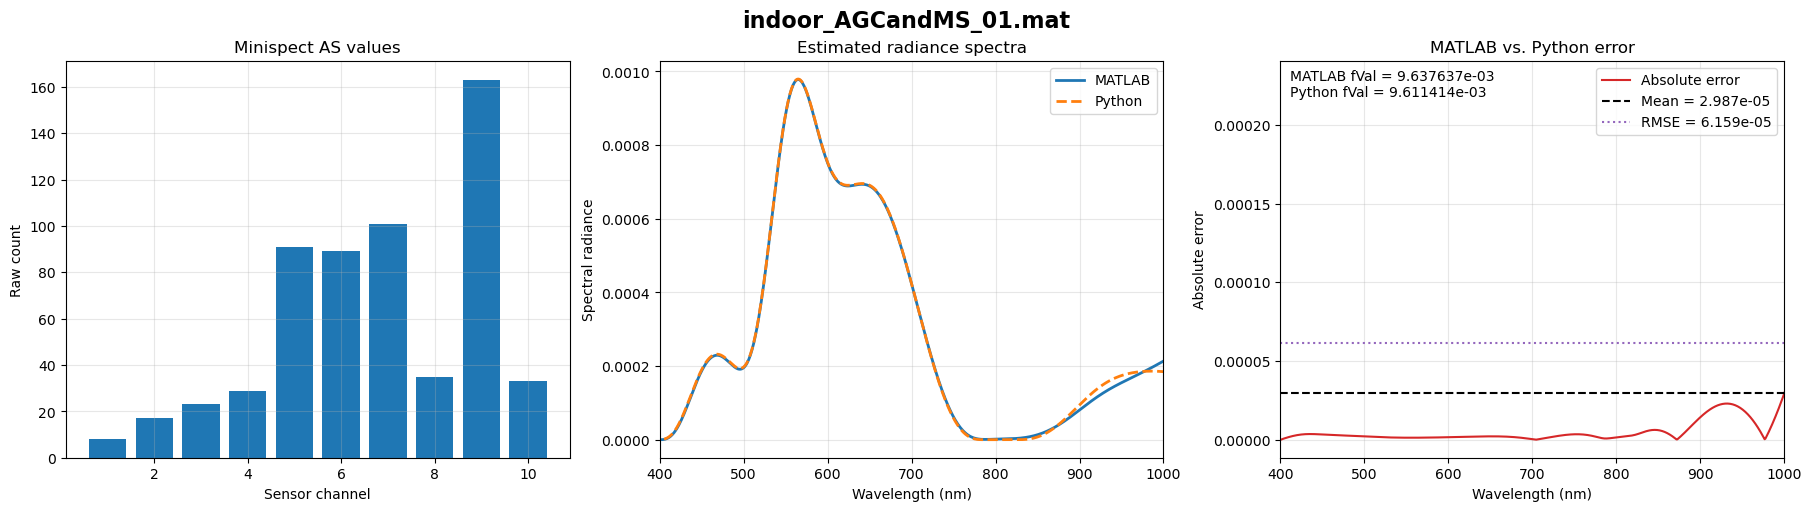

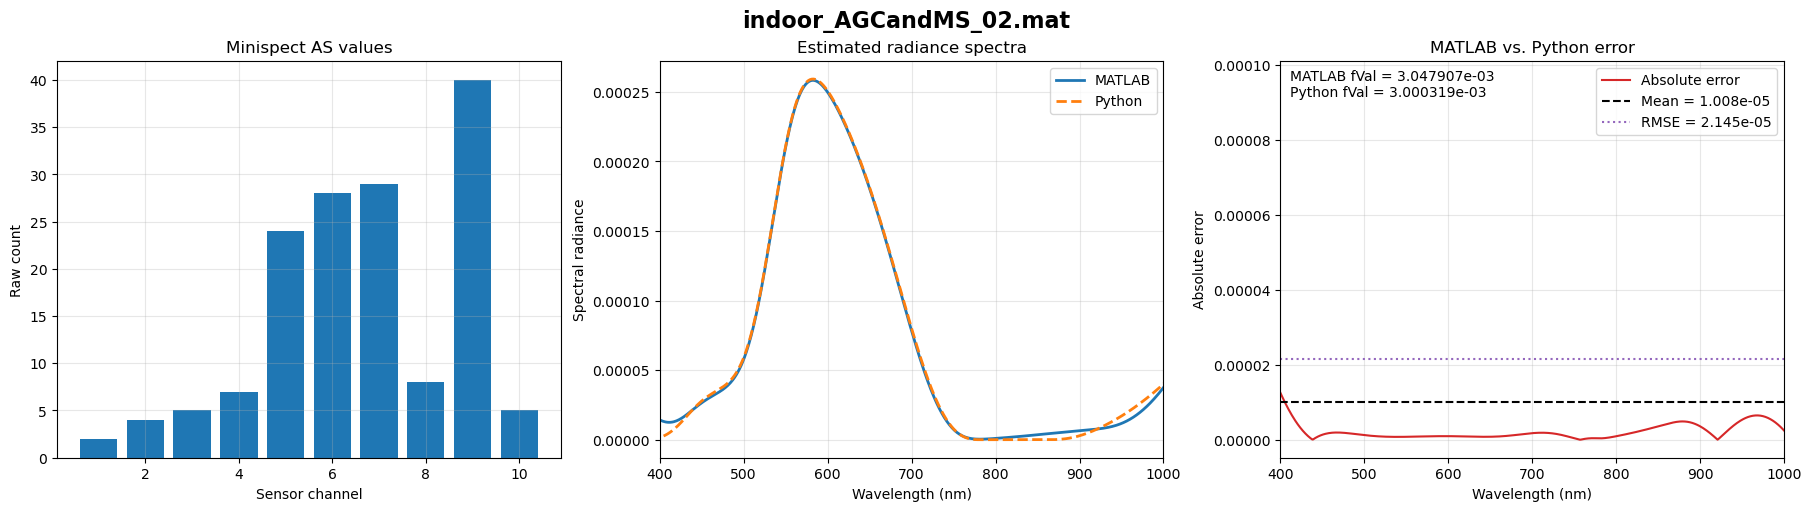

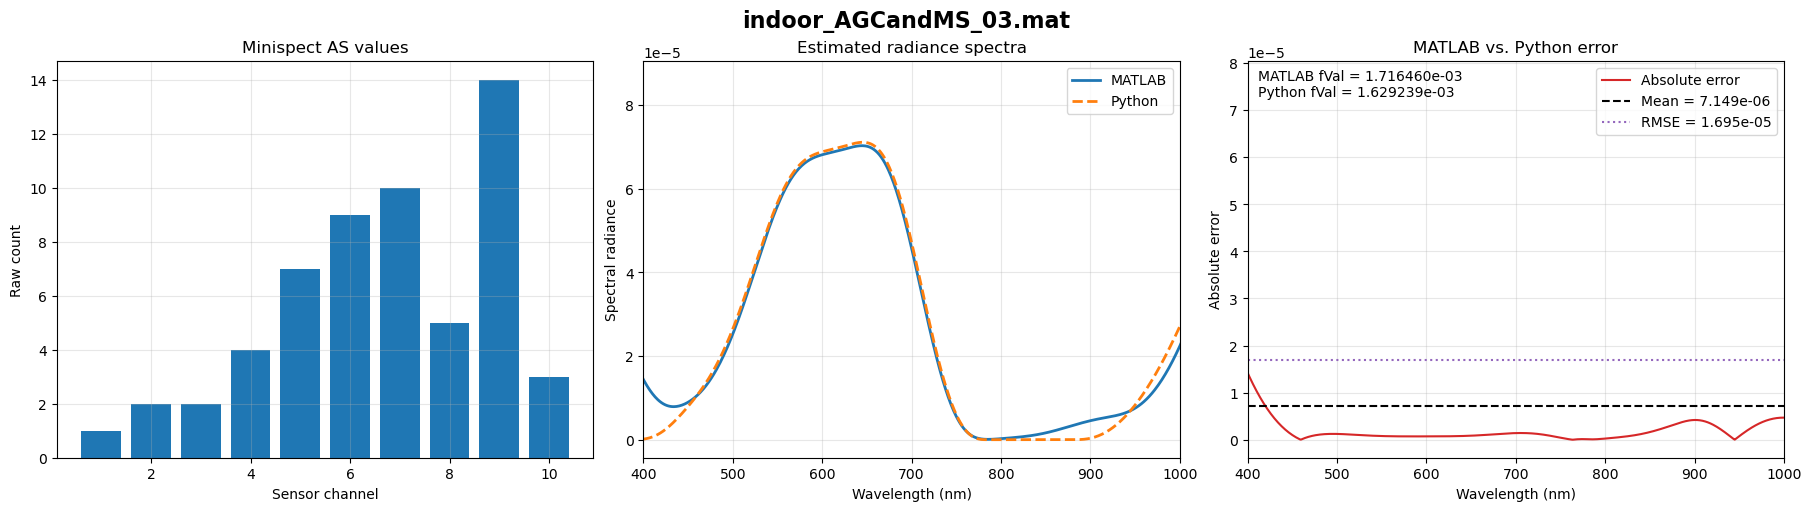

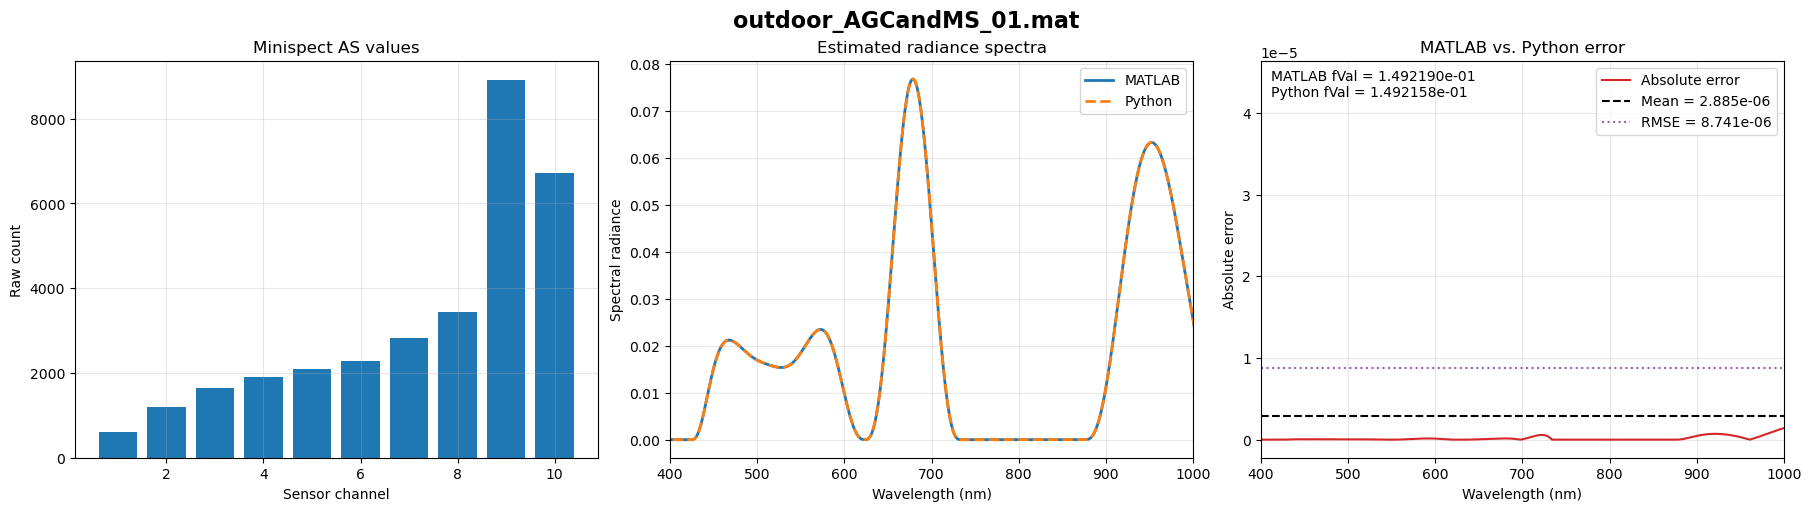

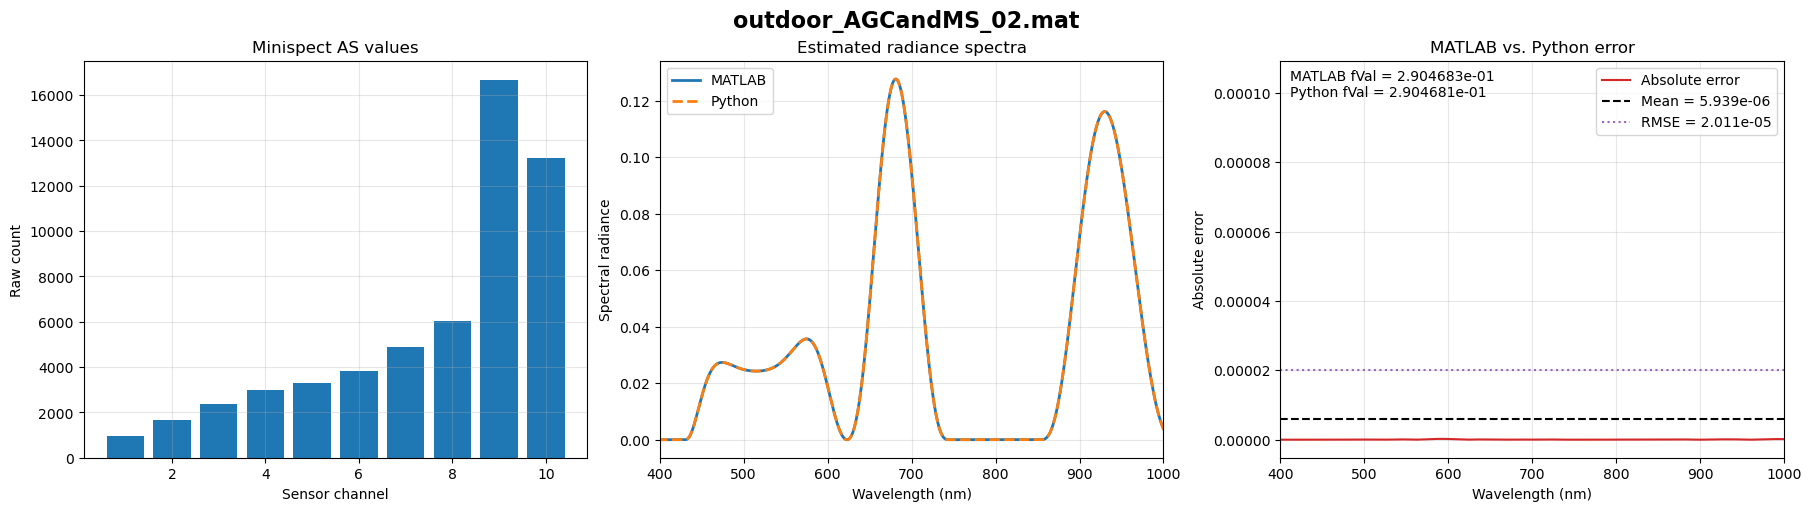

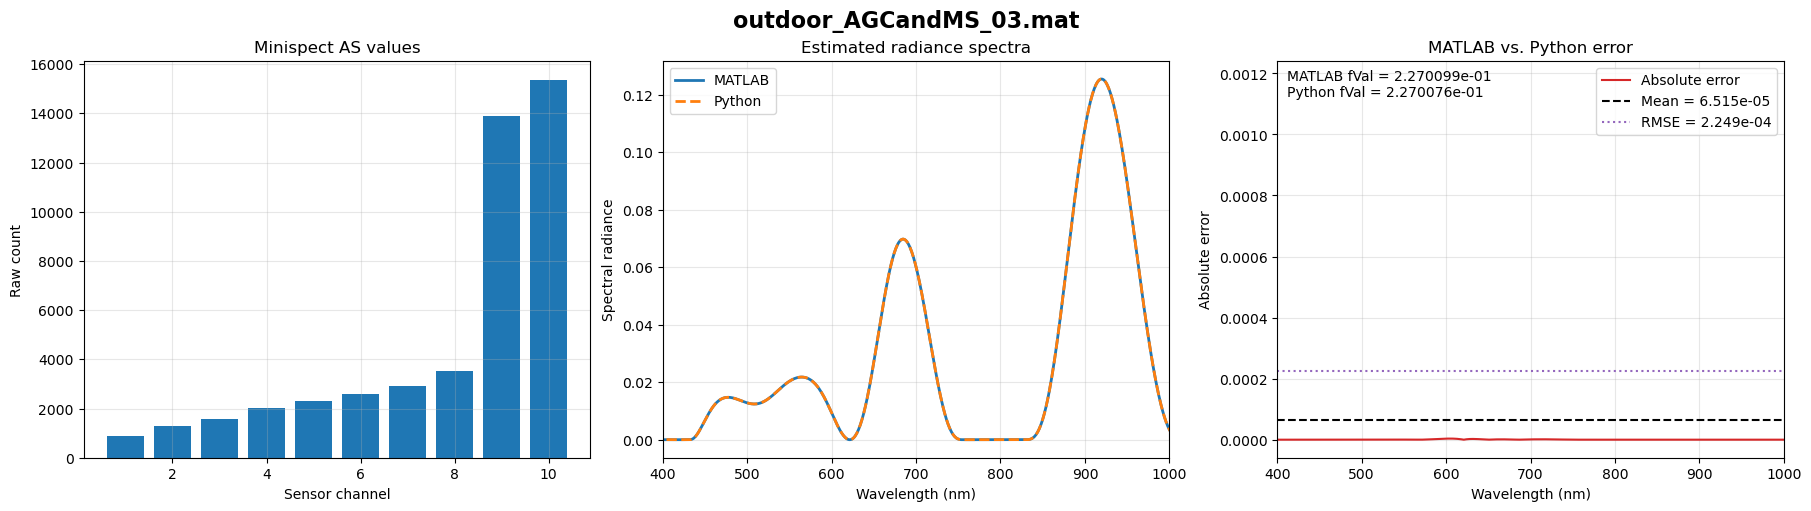

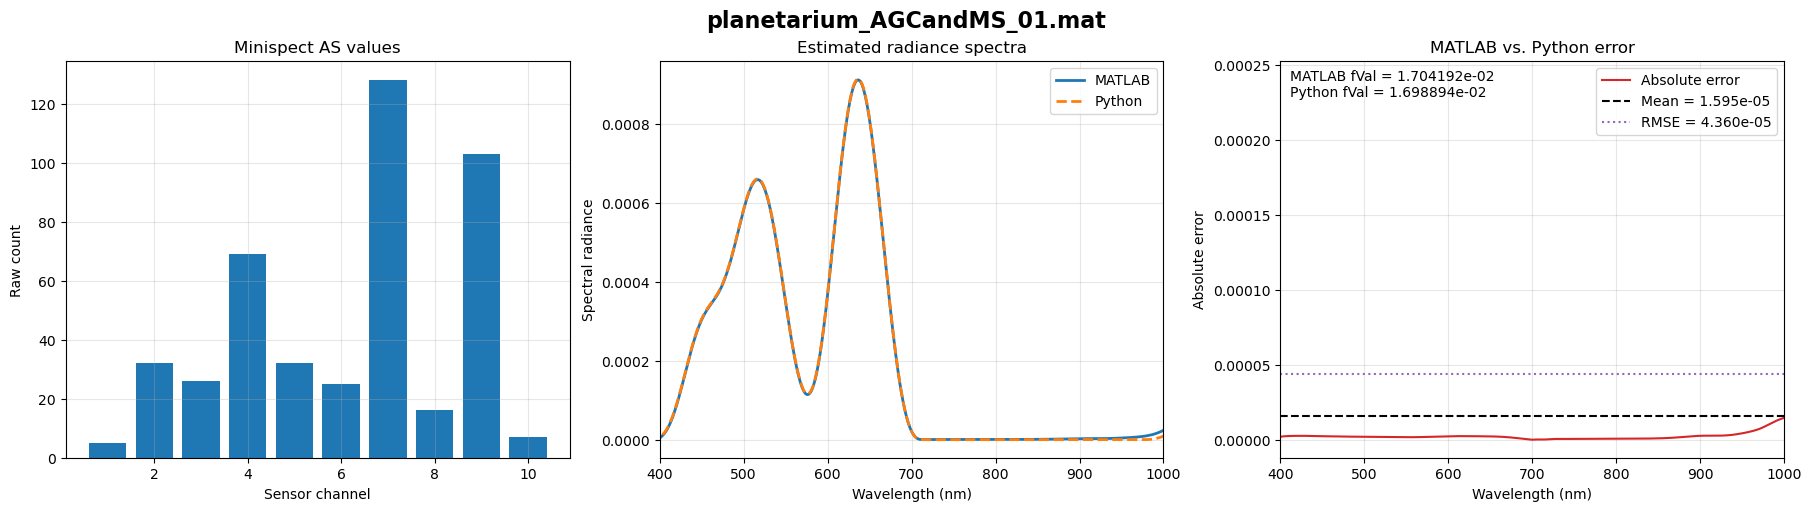

In [6]:
# Create one 1-by-3 comparison figure for every example measurement.
for measurement_path in measurement_paths:
    measurement_name: str = measurement_path.name
    output: dict[str, object] = comparison_outputs[measurement_name]

    minispect_counts: np.ndarray = output["minispect_counts"]
    matlab_spectrum: np.ndarray = output["matlab_spectrum"]
    python_spectrum: np.ndarray = output["python_spectrum"]
    matlab_sampling: np.ndarray = output["matlab_sampling"]
    absolute_error: np.ndarray = output["absolute_error"]
    matlab_f_val: float = output["matlab_f_val"]
    python_f_val: float = output["python_f_val"]

    # Expand MATLAB's [start, step, count] descriptor into wavelength values.
    wavelengths: np.ndarray = (
        matlab_sampling[0] + matlab_sampling[1] * np.arange(int(matlab_sampling[2]))
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    fig.suptitle(measurement_name, fontsize=16, fontweight="bold")

    # Show the ten raw sensor values used by both implementations.
    channel_indices: np.ndarray = np.arange(1, minispect_counts.size + 1)
    axes[0].bar(channel_indices, minispect_counts)
    axes[0].set_title("Minispect AS values")
    axes[0].set_xlabel("Sensor channel")
    axes[0].set_ylabel("Raw count")

    # Overlay the MATLAB and Python reconstructions in the second panel so
    # their agreement can be inspected directly along the same wavelength axis.
    axes[1].plot(wavelengths, matlab_spectrum, color="tab:blue", linewidth=2, label="MATLAB")
    axes[1].plot(wavelengths, python_spectrum, color="tab:orange", linestyle="--", linewidth=2, label="Python")
    axes[1].set_title("Estimated radiance spectra")
    axes[1].set_xlabel("Wavelength (nm)")
    axes[1].set_ylabel("Spectral radiance")
    axes[1].set_xlim(400, 1000)
    axes[1].legend(loc="best")

    # Summarize the finite absolute errors so the final panel shows both the
    # wavelength-by-wavelength difference and its overall scale.
    finite_absolute_error: np.ndarray = absolute_error[np.isfinite(absolute_error)]
    mean_absolute_error: float = float(np.mean(finite_absolute_error))
    rmse: float = float(np.sqrt(np.mean(finite_absolute_error ** 2)))

    # Plot one consolidated error panel with the absolute error, its mean, and RMSE.
    axes[2].plot(wavelengths, absolute_error, color="tab:red", label="Absolute error")
    axes[2].axhline(mean_absolute_error, color="black", linestyle="--", label=f"Mean = {mean_absolute_error:.3e}")
    axes[2].axhline(rmse, color="tab:purple", linestyle=":", label=f"RMSE = {rmse:.3e}")
    axes[2].set_title("MATLAB vs. Python error")
    axes[2].set_xlabel("Wavelength (nm)")
    axes[2].set_ylabel("Absolute error")
    axes[2].set_xlim(400, 1000)
    axes[2].text(
        0.02,
        0.98,
        f"MATLAB fVal = {matlab_f_val:.6e}\nPython fVal = {python_f_val:.6e}",
        transform=axes[2].transAxes,
        verticalalignment="top",
    )
    axes[2].legend(loc="best")

    # Add a grid to every panel to make values and errors easier to inspect.
    for axis in axes:
        axis.grid(True, alpha=0.3)

    plt.show()

## Interpreting the residual disagreement

The two implementations build an identical problem. Both convert the ten AS7341
channels to integrated radiance using the same calibration weights, both replace
the NIR weight with the mean of the other nine channels, both scale the
regularizer by the same signal-dependent `alpha`, and both stack the sensor model
above a second-derivative smoothness term. The wavelength sampling descriptor `S`
matches exactly.

What differs is the solver. MATLAB uses `lsqlin`, whose default is an
interior-point method, while Python uses `scipy.optimize.lsq_linear`, whose
default is a trust-region-reflective method. The problem has 801 unknowns, a
nonnegativity bound that is active for a large share of them, and a regularization
weight that grows as the scene gets dimmer. That combination is ill-conditioned,
so the two solvers stop at slightly different points on a very flat objective.

Three observations place the size of that effect:

* The **absolute** errors are small (order 1e-4) while some **relative** errors
  are large. That is expected, because the nonnegative solution pins many
  wavelength bins at or near zero, where a relative error is not meaningful.
* The residual norm `fVal` agrees to roughly 1e-5 relative for the bright outdoor
  scenes and degrades to about 5e-2 for the dimmest indoor scene, which is
  exactly the ordering the `alpha` scaling predicts.
* Evaluating the full regularized objective at each solution shows the Python
  result is very slightly **lower** than the MATLAB result for every example
  measurement. Python is therefore not converging less far than MATLAB; if
  anything it stops marginally closer to the optimum.

Switching SciPy to the exact active-set `bvls` method, or tightening `tol` to
1e-15, reproduces the trust-region answer and does not move it toward MATLAB, so
the Python implementation is left as it is. Treat `fVal` and the reconstructed
spectrum as agreeing to solver tolerance rather than to machine precision, and
compare spectra using absolute rather than relative error.